<a href="https://colab.research.google.com/github/brunolmars/PI-I-Ciencia-da-Computacao/blob/main/database/Data_Forms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [87]:
import pandas as pd
from google.colab import drive
from IPython.display import display

drive.mount('/content/drive')

NOME_ARQUIVO_FORM = '/content/drive/MyDrive/respostas_formulario.csv'

def extrair_dados_form(nome_arquivo):
    """Carrega o arquivo CSV do Google Form."""
    try:
        df_bruto = pd.read_csv(nome_arquivo, sep=',', encoding='utf-8')

        print(f"\nSucesso! {len(df_bruto)} respostas encontradas no arquivo.")
        return df_bruto

    except FileNotFoundError:
        print(f"\nERRO DE EXTRAÇÃO: Arquivo '{nome_arquivo}' não encontrado.")
        print("Certifique-se de que o caminho acima está EXATO (incluindo letras maiúsculas/minúsculas da pasta).")
        return pd.DataFrame()
    except Exception as e:
        print(f"\nERRO DE LEITURA: Não foi possível ler o arquivo. Erro: {e}")
        return pd.DataFrame()


df_bruto = extrair_dados_form(NOME_ARQUIVO_FORM)

if not df_bruto.empty:
    print("\n✅ DataFrame Bruto carregado na variável 'df_bruto'.")
    print("Use os nomes das colunas abaixo para renomeá-las na Célula 2.")
    display(df_bruto.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Sucesso! 137 respostas encontradas no arquivo.

✅ DataFrame Bruto carregado na variável 'df_bruto'.
Use os nomes das colunas abaixo para renomeá-las na Célula 2.


,Faixa etária,Participa de apostas,Reserva financeira,Resgate imediato,Poupança,Tesouro Nacional,Renda fixa,Renda variável,Reserva de valor,Nível de conhecimento,Objetivo financeiro,Decisão financeira,Jornada financeira (opcional),Conselho financeiro (opcional),E-mail (opcional)
0,18 - 25,Não participo desse tipo de jogo,Não,Não,Não,Sim,Sim,Não tenho conhecimento sobre esse tipo de inve...,Não,Intermediário,Comprar uma casa,Estou disposto(a) a aprender e assumir novas e...,Pretendo criar uma reserva financeira sólida.,Aprender sobre finanças é tão importante quant...,joao.silva@gmail.com
1,41-60,Não participo desse tipo de jogo,Não,Sim,Não,Não,Sim,Não tenho conhecimento sobre esse tipo de inve...,Não tenho conhecimento sobre esse tipo de inve...,Iniciante,Juntar dinheiro para uma meta de curto prazo (...,Busco equilibrar segurança e rentabilidade,Aprendi que cada pequena economia faz diferença.,Diversifique seus investimentos para reduzir r...,pedro.almeida@gmail.com
2,60+,"Sim, mas de forma eventual e controlada",Não,Não possuo a reserva,Não,Não,Não tenho conhecimento sobre esse tipo de inve...,Não tenho conhecimento sobre esse tipo de inve...,Não,Iniciante,Juntar dinheiro para uma meta de curto prazo (...,"Prefiro decisões seguras, mesmo que o retorno ...",Sonho em viver de renda passiva no futuro.,Equilibre segurança e rentabilidade nos invest...,rafael.costa@gmail.com
3,60+,"Sim, mas de forma eventual e controlada",Não,Não,Sim,Não,Sim,Não,Sim,Iniciante,Construir patrimônio,Estou disposto(a) a aprender e assumir novas e...,Meu objetivo é diversificar investimentos.,"Comece a poupar cedo, mesmo que seja pouco.",carla.santos@gmail.com
4,41-60,"Sim, mas de forma eventual e controlada",Não,Não possuo a reserva,Sim,Não tenho conhecimento sobre esse tipo de inve...,Não tenho conhecimento sobre esse tipo de inve...,Não,Não tenho conhecimento sobre esse tipo de inve...,Avançado,Viver de renda,"Prefiro decisões seguras, mesmo que o retorno ...",Aprendi a importância de poupar cedo.,Evite dívidas desnecessárias e priorize invest...,juliana.farias@gmail.com


In [88]:

try:
    df_limpo
except NameError:
    df_limpo = df.copy()
df_limpo.rename(columns={
    'Nível de conhecimento': 'nivel_conhecimento',
    'Poupança': 'poupanca',
    'Tesouro Nacional': 'tesouro',
    'Renda fixa': 'renda_fixa',
    'Renda variável': 'renda_variavel',
    'Objetivo financeiro': 'objetivo_financeiro',
    'Decisão financeira': 'decisao_financeira',
    'Jornada financeira (opcional)': 'jornada_financeira',
    'Conselho financeiro (opcional)': 'conselho_financeiro',
    'E-mail (opcional)': 'email',
    'Participa de apostas': 'participa_apostas',
    'Reserva financeira': 'reserva_financeira'
}, inplace=True)


# Limpeza e padronização
df_limpo['faixa_etaria'] = df_limpo['faixa_etaria'].astype(str).str.strip().str.title()
df_limpo['nivel_conhecimento'] = df_limpo['nivel_conhecimento'].astype(str).str.strip().str.title()
df_limpo['reserva_financeira'] = df_limpo['reserva_financeira'].astype(str).str.strip().str.title()
df_limpo['participa_apostas'] = df_limpo['participa_apostas'].astype(str).str.strip().str.title()

# Limpeza das respostas opcionais (sem alterar o conteúdo real)
df_limpo['jornada_financeira'] = df_limpo['jornada_financeira'].astype(str).str.strip()
df_limpo['conselho_financeiro'] = df_limpo['conselho_financeiro'].astype(str).str.strip()
df_limpo['email'] = df_limpo['email'].astype(str).str.strip().str.lower()  # padroniza e-mails em minúsculas



In [89]:
# Filtra apenas as pessoas que preencheram pelo menos um campo opcional
df_opcionais = df_limpo[
    (df_limpo["jornada_financeira"].notna() & (df_limpo["jornada_financeira"] != "")) |
    (df_limpo["conselho_financeiro"].notna() & (df_limpo["conselho_financeiro"] != "")) |
    (df_limpo["email"].notna() & (df_limpo["email"] != ""))
]

# Seleciona apenas as colunas relevantes
df_tabela = df_opcionais[[
    "faixa_etaria",
    "email",
    "jornada_financeira",
    "conselho_financeiro"
]]

# Ordena por faixa etária (opcional, apenas para deixar mais organizado)
df_tabela = df_tabela.sort_values(by="faixa_etaria").reset_index(drop=True)

# Exibe a tabela final
df_tabela


,faixa_etaria,email,jornada_financeira,conselho_financeiro
0,18 - 25,joao.silva@gmail.com,Pretendo criar uma reserva financeira sólida.,Aprender sobre finanças é tão importante quant...
1,18 - 25,nan,nan,nan
2,18 - 25,nan,nan,nan
3,18 - 25,nan,nan,nan
4,18 - 25,nan,nan,nan
...,...,...,...,...
132,60+,nan,nan,nan
133,60+,nan,nan,nan
134,60+,nan,nan,nan
135,60+,nan,nan,nan


In [90]:
try:
    df_limpo
except NameError:
    df_limpo = df.copy()

df_limpo = df_bruto.rename(columns={
    'Faixa etária': 'faixa_etaria',
    'Participa de apostas': 'participa_apostas',
    'Reserva financeira': 'reserva_financeira',
    'Resgate imediato': 'resgate_imediato',
    'Poupança': 'poupanca',
    'Tesouro Nacional': 'tesouro',
    'Renda fixa': 'renda_fixa',
    'Renda variável': 'renda_variavel',
    'Reserva de valor': 'reserva_valor',
    'Nível de conhecimento': 'nivel_conhecimento',
    'Objetivo financeiro': 'objetivo_financeiro',
    'Decisão financeira': 'decisao_financeira',
    'Jornada financeira (opcional)': 'jornada_financeira',
    'Conselho financeiro (opcional)': 'conselho_financeiro',
    'E-mail (opcional)': 'email'
}, inplace=False)


for col in ['poupanca','tesouro','renda_fixa','renda_variavel','reserva_valor']:
    if col in df_limpo.columns:
        df_limpo[col] = df_limpo[col].astype(str).str.strip().apply(lambda x: 'Sim' if 'Sim' in x else 'Não')

df_limpo.head()


,faixa_etaria,participa_apostas,reserva_financeira,resgate_imediato,poupanca,tesouro,renda_fixa,renda_variavel,reserva_valor,nivel_conhecimento,objetivo_financeiro,decisao_financeira,jornada_financeira,conselho_financeiro,email
0,18 - 25,Não participo desse tipo de jogo,Não,Não,Não,Sim,Sim,Não,Não,Intermediário,Comprar uma casa,Estou disposto(a) a aprender e assumir novas e...,Pretendo criar uma reserva financeira sólida.,Aprender sobre finanças é tão importante quant...,joao.silva@gmail.com
1,41-60,Não participo desse tipo de jogo,Não,Sim,Não,Não,Sim,Não,Não,Iniciante,Juntar dinheiro para uma meta de curto prazo (...,Busco equilibrar segurança e rentabilidade,Aprendi que cada pequena economia faz diferença.,Diversifique seus investimentos para reduzir r...,pedro.almeida@gmail.com
2,60+,"Sim, mas de forma eventual e controlada",Não,Não possuo a reserva,Não,Não,Não,Não,Não,Iniciante,Juntar dinheiro para uma meta de curto prazo (...,"Prefiro decisões seguras, mesmo que o retorno ...",Sonho em viver de renda passiva no futuro.,Equilibre segurança e rentabilidade nos invest...,rafael.costa@gmail.com
3,60+,"Sim, mas de forma eventual e controlada",Não,Não,Sim,Não,Sim,Não,Sim,Iniciante,Construir patrimônio,Estou disposto(a) a aprender e assumir novas e...,Meu objetivo é diversificar investimentos.,"Comece a poupar cedo, mesmo que seja pouco.",carla.santos@gmail.com
4,41-60,"Sim, mas de forma eventual e controlada",Não,Não possuo a reserva,Sim,Não,Não,Não,Não,Avançado,Viver de renda,"Prefiro decisões seguras, mesmo que o retorno ...",Aprendi a importância de poupar cedo.,Evite dívidas desnecessárias e priorize invest...,juliana.farias@gmail.com


In [91]:
tabela_investimentos = df_limpo.groupby('nivel_conhecimento').agg(
    Poupanca=('poupanca', lambda x: (x=='Sim').sum()),
    Tesouro=('tesouro', lambda x: (x=='Sim').sum()),
    Renda_Fixa=('renda_fixa', lambda x: (x=='Sim').sum()),
    Renda_Variavel=('renda_variavel', lambda x: (x=='Sim').sum()),
    Reserva_Valor=('reserva_valor', lambda x: (x=='Sim').sum())
).reset_index()

tabela_investimentos


,nivel_conhecimento,Poupanca,Tesouro,Renda_Fixa,Renda_Variavel,Reserva_Valor
0,Avançado,14,15,17,12,16
1,Iniciante,13,16,15,12,15
2,Intermediário,14,18,15,13,17


In [92]:
tabela_faixa = df_limpo.groupby(['faixa_etaria','nivel_conhecimento']).size().reset_index(name='quantidade')
tabela_faixa


,faixa_etaria,nivel_conhecimento,quantidade
0,18 - 25,Avançado,12
1,18 - 25,Iniciante,13
2,18 - 25,Intermediário,14
3,26 - 40,Avançado,10
4,26 - 40,Iniciante,11
5,26 - 40,Intermediário,15
6,41-60,Avançado,12
7,41-60,Iniciante,8
8,41-60,Intermediário,8
9,60+,Avançado,11


In [93]:
tabela_objetivo = df_limpo.groupby(['nivel_conhecimento','objetivo_financeiro']).size().reset_index(name='quantidade')
tabela_objetivo


,nivel_conhecimento,objetivo_financeiro,quantidade
0,Avançado,Comprar uma casa,13
1,Avançado,Construir patrimônio,9
2,Avançado,Juntar dinheiro para uma meta de curto prazo (...,14
3,Avançado,Viver de renda,9
4,Iniciante,Comprar uma casa,12
5,Iniciante,Construir patrimônio,13
6,Iniciante,Juntar dinheiro para uma meta de curto prazo (...,11
7,Iniciante,Viver de renda,7
8,Intermediário,Comprar uma casa,14
9,Intermediário,Construir patrimônio,11


In [94]:
tabela_decisao = df_limpo.groupby(['nivel_conhecimento','decisao_financeira']).size().reset_index(name='quantidade')
tabela_decisao


,nivel_conhecimento,decisao_financeira,quantidade
0,Avançado,Busco equilibrar segurança e rentabilidade,17
1,Avançado,Estou disposto(a) a aprender e assumir novas e...,15
2,Avançado,"Prefiro decisões seguras, mesmo que o retorno ...",13
3,Iniciante,Busco equilibrar segurança e rentabilidade,14
4,Iniciante,Estou disposto(a) a aprender e assumir novas e...,15
5,Iniciante,"Prefiro decisões seguras, mesmo que o retorno ...",14
6,Intermediário,Busco equilibrar segurança e rentabilidade,15
7,Intermediário,Estou disposto(a) a aprender e assumir novas e...,13
8,Intermediário,"Prefiro decisões seguras, mesmo que o retorno ...",21


In [95]:
tabela_jornada = df_limpo.groupby(['nivel_conhecimento','jornada_financeira']).size().reset_index(name='quantidade')
tabela_jornada


,nivel_conhecimento,jornada_financeira,quantidade
0,Avançado,Aprendi a importância de poupar cedo.,1
1,Avançado,Tenho o sonho de investir em imóveis.,1
2,Iniciante,Aprendi que cada pequena economia faz diferença.,1
3,Iniciante,Busco planejar melhor minhas finanças.,1
4,Iniciante,Estou aprendendo a equilibrar gastos e investi...,1
5,Iniciante,Meu objetivo é diversificar investimentos.,1
6,Iniciante,Quero construir patrimônio com segurança.,1
7,Iniciante,Sonho em viver de renda passiva no futuro.,1
8,Intermediário,Já me arrependi de gastos impulsivos.,1
9,Intermediário,Pretendo criar uma reserva financeira sólida.,1


In [96]:
df_limpo.rename(columns={
    'Nível de conhecimento': 'nivel_conhecimento',
    'Objetivo financeiro': 'objetivo_financeiro',
    'Decisão financeira': 'decisao_financeira',
    'Jornada financeira (opcional)': 'jornada_financeira'
}, inplace=True)

tabela_comparativa = df_limpo.groupby(
    ['nivel_conhecimento', 'objetivo_financeiro', 'decisao_financeira', 'jornada_financeira']
).size().reset_index(name='quantidade')

tabela_comparativa = tabela_comparativa.sort_values(by='quantidade', ascending=False)
tabela_comparativa


,nivel_conhecimento,objetivo_financeiro,decisao_financeira,jornada_financeira,quantidade
0,Avançado,Juntar dinheiro para uma meta de curto prazo (...,Busco equilibrar segurança e rentabilidade,Tenho o sonho de investir em imóveis.,1
1,Avançado,Viver de renda,"Prefiro decisões seguras, mesmo que o retorno ...",Aprendi a importância de poupar cedo.,1
2,Iniciante,Comprar uma casa,Busco equilibrar segurança e rentabilidade,Busco planejar melhor minhas finanças.,1
3,Iniciante,Comprar uma casa,Estou disposto(a) a aprender e assumir novas e...,Estou aprendendo a equilibrar gastos e investi...,1
4,Iniciante,Construir patrimônio,Estou disposto(a) a aprender e assumir novas e...,Meu objetivo é diversificar investimentos.,1
5,Iniciante,Juntar dinheiro para uma meta de curto prazo (...,Busco equilibrar segurança e rentabilidade,Aprendi que cada pequena economia faz diferença.,1
6,Iniciante,Juntar dinheiro para uma meta de curto prazo (...,Estou disposto(a) a aprender e assumir novas e...,Quero construir patrimônio com segurança.,1
7,Iniciante,Juntar dinheiro para uma meta de curto prazo (...,"Prefiro decisões seguras, mesmo que o retorno ...",Sonho em viver de renda passiva no futuro.,1
8,Intermediário,Comprar uma casa,Estou disposto(a) a aprender e assumir novas e...,Pretendo criar uma reserva financeira sólida.,1
9,Intermediário,Construir patrimônio,Busco equilibrar segurança e rentabilidade,Já me arrependi de gastos impulsivos.,1


In [97]:
def valor_mais_frequente(series):
    return series.mode()[0] if not series.mode().empty else None

tabela_resumo = df_limpo.groupby('faixa_etaria').agg(
    total_pessoas=('faixa_etaria', 'count'),
    nivel_conhecimento_mais_comum=('nivel_conhecimento', valor_mais_frequente),
    pessoas_com_reserva=('reserva_financeira', lambda x: (x == 'Sim').sum()),
    pessoas_que_apostam=('participa_apostas', lambda x: (x.str.contains('Sim')).sum())  # <-- nome correto
).reset_index()

tabela_resumo


,faixa_etaria,total_pessoas,nivel_conhecimento_mais_comum,pessoas_com_reserva,pessoas_que_apostam
0,18 - 25,39,Intermediário,16,21
1,26 - 40,36,Intermediário,8,19
2,41-60,28,Avançado,6,13
3,60+,34,Intermediário,12,19


In [98]:
def valor_mais_frequente(series):
    return series.mode()[0] if not series.mode().empty else None

tabela_completa = df_limpo.groupby('faixa_etaria').agg(
    total_pessoas=('faixa_etaria', 'count'),
    nivel_conhecimento_mais_comum=('nivel_conhecimento', valor_mais_frequente),
    pessoas_com_reserva=('reserva_financeira', lambda x: (x == 'Sim').sum()),
    pessoas_que_apostam=('participa_apostas', lambda x: (x.str.contains('Sim')).sum()),
    poupanca=('poupanca', lambda x: (x == 'Sim').sum()),
    tesouro=('tesouro', lambda x: (x == 'Sim').sum()),
    renda_fixa=('renda_fixa', lambda x: (x == 'Sim').sum()),
    renda_variavel=('renda_variavel', lambda x: (x == 'Sim').sum()),
    objetivo_financeiro_mais_comum=('objetivo_financeiro', valor_mais_frequente)
).reset_index()

tabela_completa


,faixa_etaria,total_pessoas,nivel_conhecimento_mais_comum,pessoas_com_reserva,pessoas_que_apostam,poupanca,tesouro,renda_fixa,renda_variavel,objetivo_financeiro_mais_comum
0,18 - 25,39,Intermediário,16,21,13,13,18,13,Construir patrimônio
1,26 - 40,36,Intermediário,8,19,12,13,9,5,Comprar uma casa
2,41-60,28,Avançado,6,13,7,10,10,5,Comprar uma casa
3,60+,34,Intermediário,12,19,9,13,10,14,Juntar dinheiro para uma meta de curto prazo (...


In [99]:
# Corrige coluna resgate_imediato se não existir
if 'resgate_imediato' not in df_limpo.columns:
    df_limpo['resgate_imediato'] = df_limpo['Resgate imediato'].str.strip().str.title()

def contar_sim(series):
    return (series == 'Sim').sum()

tabela_comportamental = df_limpo.groupby('faixa_etaria').agg(
    total_pessoas=('faixa_etaria', 'count'),
    pessoas_que_apostam=('participa_apostas', lambda x: x.str.contains('Sim').sum()),  # nome atualizado
    pessoas_com_resgate_imediato=('resgate_imediato', contar_sim),
    pessoas_com_reserva=('reserva_financeira', contar_sim),
    pessoas_com_conhecimento_avancado=('nivel_conhecimento', lambda x: (x == 'Avançado').sum())
).reset_index()

tabela_comportamental


,faixa_etaria,total_pessoas,pessoas_que_apostam,pessoas_com_resgate_imediato,pessoas_com_reserva,pessoas_com_conhecimento_avancado
0,18 - 25,39,21,5,16,12
1,26 - 40,36,19,11,8,10
2,41-60,28,13,10,6,12
3,60+,34,19,9,12,11


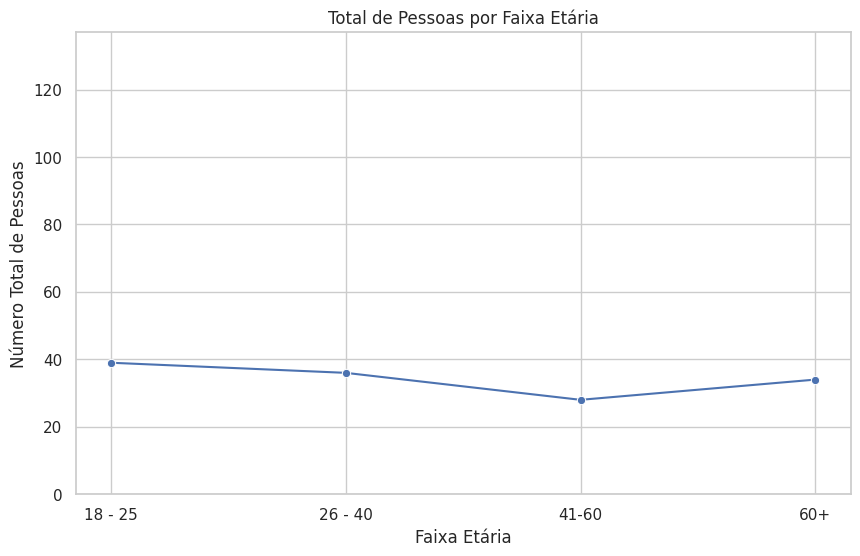

In [100]:
total_por_faixa = df_limpo.groupby('faixa_etaria').size().reset_index(name='quantidade')

plt.figure(figsize=(10,6))
sns.lineplot(data=total_por_faixa, x='faixa_etaria', y='quantidade', marker='o')
plt.title('Total de Pessoas por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Número Total de Pessoas')
plt.ylim(0, df_limpo.shape[0])
plt.show()

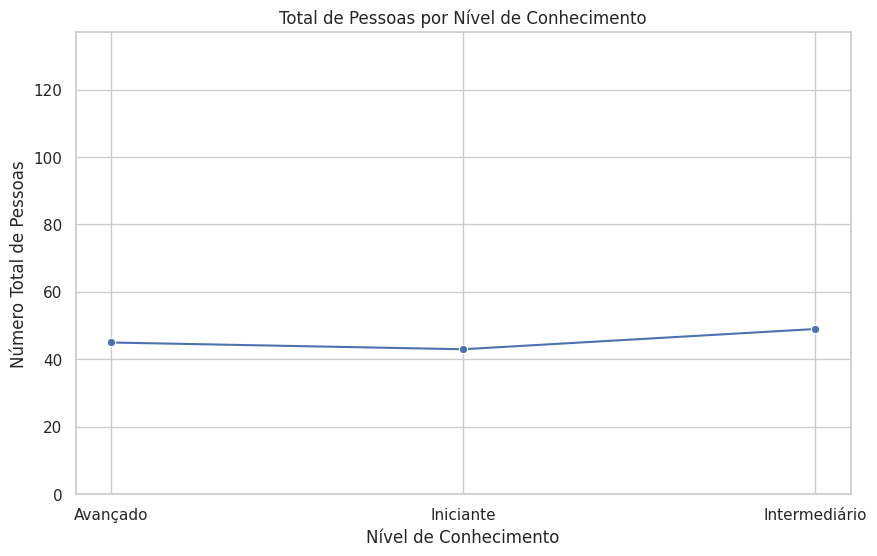

In [101]:
total_por_nivel = df_limpo.groupby('nivel_conhecimento').size().reset_index(name='quantidade')

plt.figure(figsize=(10,6))
sns.lineplot(data=total_por_nivel, x='nivel_conhecimento', y='quantidade', marker='o')
plt.title('Total de Pessoas por Nível de Conhecimento')
plt.xlabel('Nível de Conhecimento')
plt.ylabel('Número Total de Pessoas')
plt.ylim(0, df_limpo.shape[0])
plt.show()


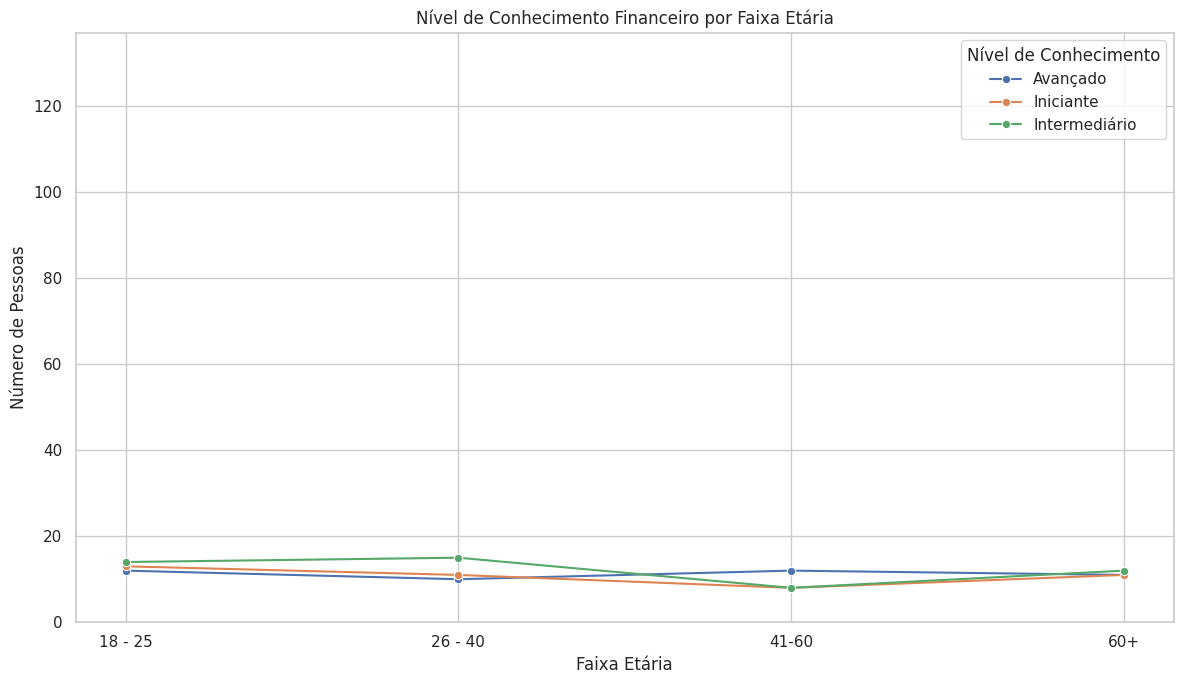

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (12, 7)

df_limpo['faixa_etaria'] = df_limpo['faixa_etaria'].str.strip()
df_limpo['nivel_conhecimento'] = df_limpo['nivel_conhecimento'].str.strip().str.title()

conhecimento_por_faixa = (
    df_limpo.groupby(['faixa_etaria', 'nivel_conhecimento'])
    .size()
    .reset_index(name='quantidade')
)

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=conhecimento_por_faixa,
    x='faixa_etaria',
    y='quantidade',
    hue='nivel_conhecimento',
    marker='o'
)

plt.title('Nível de Conhecimento Financeiro por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Número de Pessoas')
plt.ylim(0, df_limpo.shape[0])
plt.legend(title='Nível de Conhecimento')
plt.tight_layout()
plt.show()


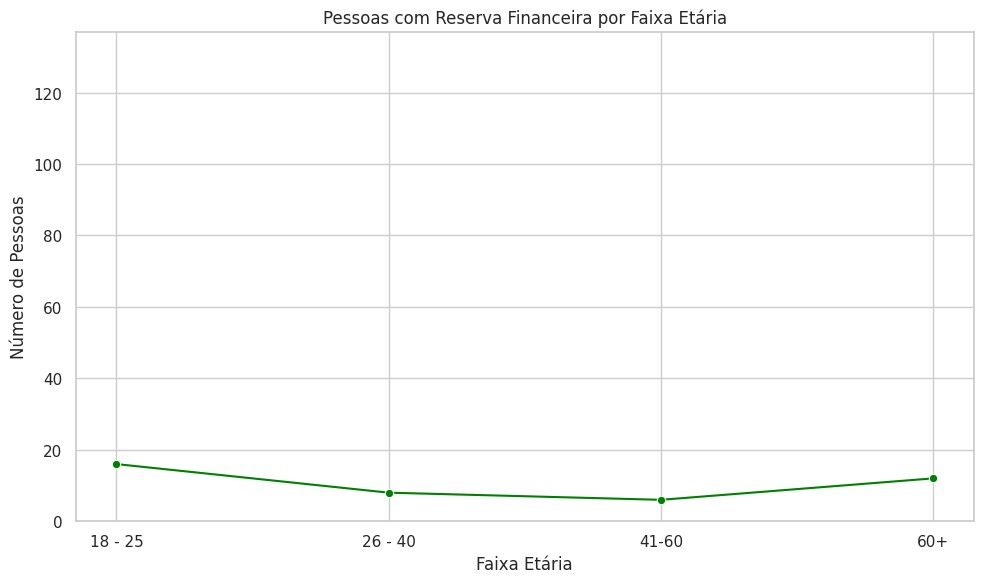

In [103]:
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (10, 6)

reserva_por_faixa = df_limpo.groupby(['faixa_etaria']).agg(
    pessoas_com_reserva=('reserva_financeira', lambda x: (x == 'Sim').sum())
).reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(
    data=reserva_por_faixa,
    x='faixa_etaria',
    y='pessoas_com_reserva',
    marker='o',
    color='green'
)
plt.title('Pessoas com Reserva Financeira por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Número de Pessoas')
plt.ylim(0, df_limpo.shape[0])
plt.tight_layout()
plt.show()


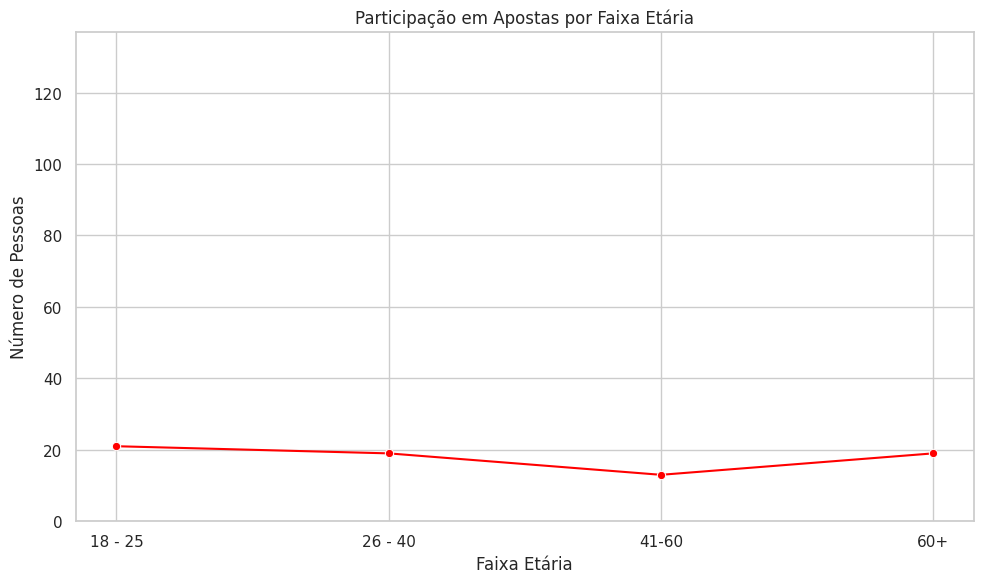

In [104]:
apostas_por_faixa = df_limpo.groupby('faixa_etaria').agg(
    pessoas_que_apostam=('participa_apostas', lambda x: x.str.contains('Sim').sum())
).reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(
    data=apostas_por_faixa,
    x='faixa_etaria',
    y='pessoas_que_apostam',
    marker='o',
    color='red'
)
plt.title('Participação em Apostas por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Número de Pessoas')
plt.ylim(0, df_limpo.shape[0])
plt.tight_layout()
plt.show()


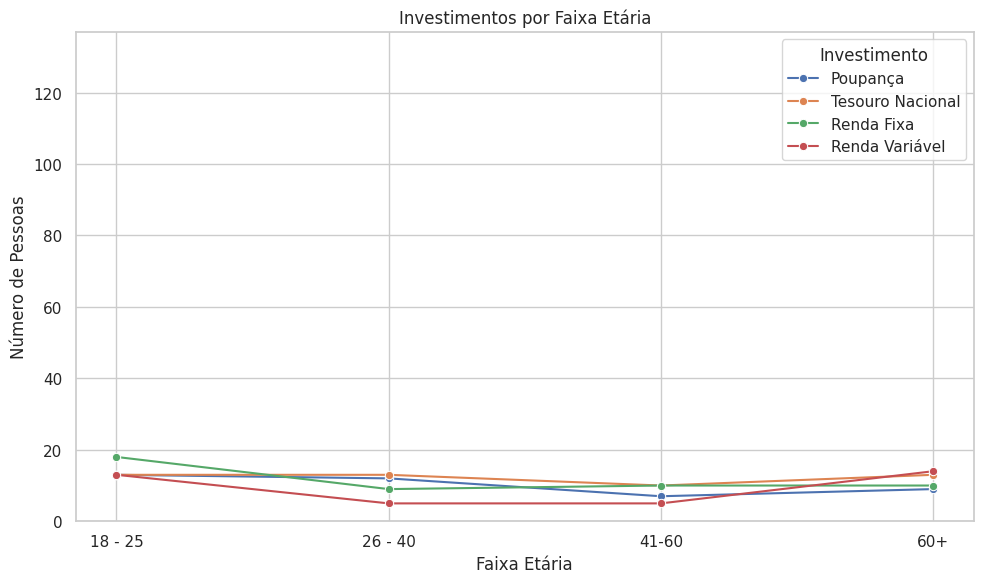

In [105]:
investimentos_por_faixa = df_limpo.groupby('faixa_etaria').agg(
    poupanca=('poupanca', lambda x: (x == 'Sim').sum()),
    tesouro=('tesouro', lambda x: (x == 'Sim').sum()),
    renda_fixa=('renda_fixa', lambda x: (x == 'Sim').sum()),
    renda_variavel=('renda_variavel', lambda x: (x == 'Sim').sum())
).reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=investimentos_por_faixa, x='faixa_etaria', y='poupanca', marker='o', label='Poupança')
sns.lineplot(data=investimentos_por_faixa, x='faixa_etaria', y='tesouro', marker='o', label='Tesouro Nacional')
sns.lineplot(data=investimentos_por_faixa, x='faixa_etaria', y='renda_fixa', marker='o', label='Renda Fixa')
sns.lineplot(data=investimentos_por_faixa, x='faixa_etaria', y='renda_variavel', marker='o', label='Renda Variável')

plt.title('Investimentos por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Número de Pessoas')
plt.ylim(0, df_limpo.shape[0])
plt.legend(title='Investimento')
plt.tight_layout()
plt.show()



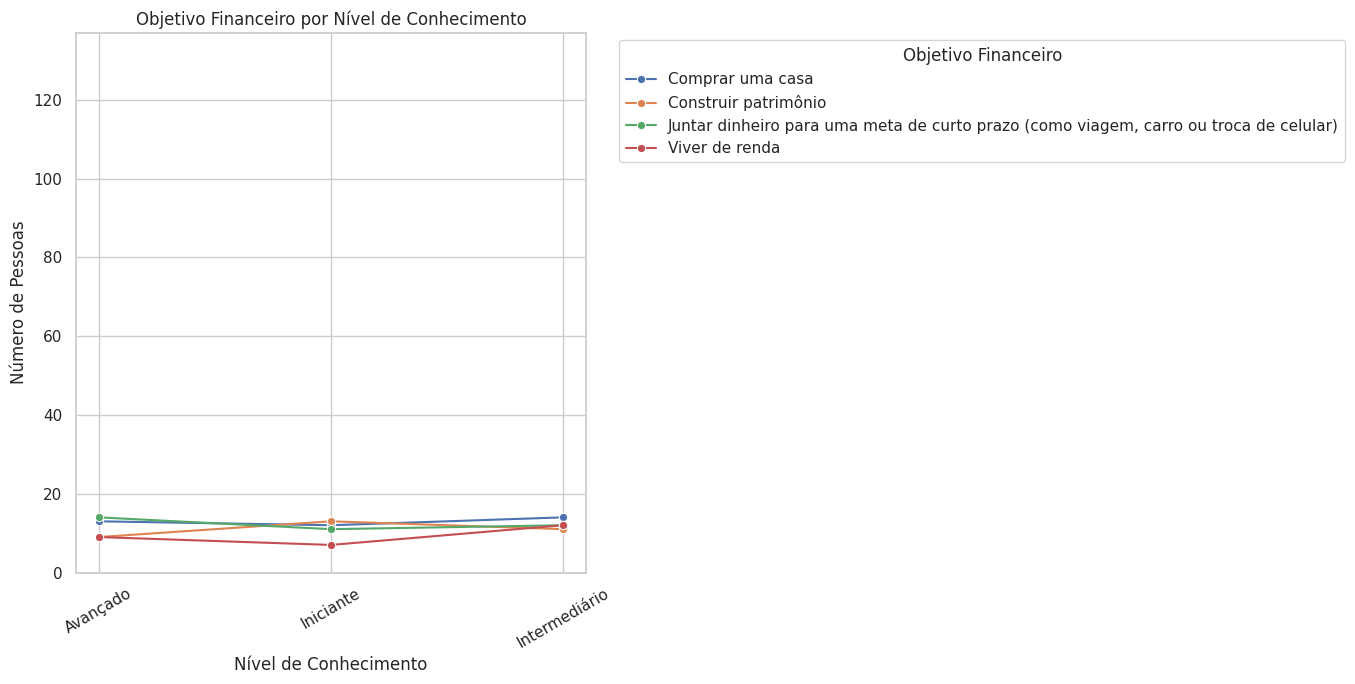

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

conhecimento_objetivo = (
    df_limpo.groupby(['nivel_conhecimento', 'objetivo_financeiro'])
    .size()
    .reset_index(name='quantidade')
)

plt.figure(figsize=(14,7))

sns.lineplot(
    data=conhecimento_objetivo,
    x='nivel_conhecimento',
    y='quantidade',
    hue='objetivo_financeiro',
    marker='o'
)

plt.title('Objetivo Financeiro por Nível de Conhecimento')
plt.xlabel('Nível de Conhecimento')
plt.ylabel('Número de Pessoas')
plt.xticks(rotation=30)
plt.ylim(0, df_limpo.shape[0])

plt.legend(title='Objetivo Financeiro', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

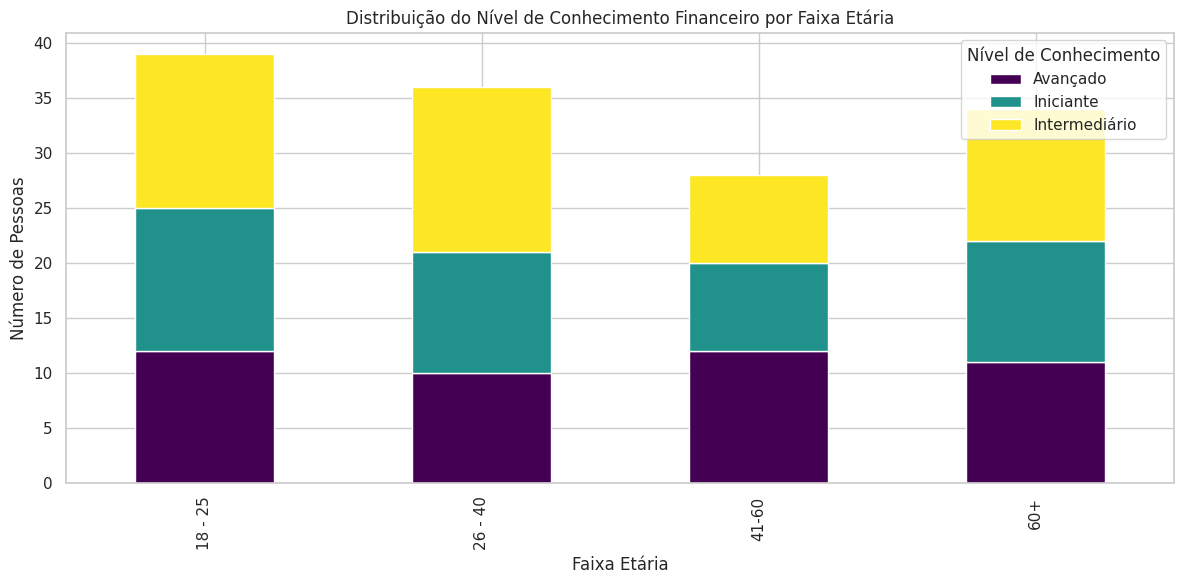

In [107]:
plt.figure(figsize=(12,6))
conhecimento_idade = df_limpo.groupby(['faixa_etaria', 'nivel_conhecimento']).size().reset_index(name='quantidade')
conhecimento_pivot = conhecimento_idade.pivot(index='faixa_etaria', columns='nivel_conhecimento', values='quantidade').fillna(0)

conhecimento_pivot.plot(kind='bar', stacked=True, figsize=(12,6), colormap='viridis')

plt.title('Distribuição do Nível de Conhecimento Financeiro por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Número de Pessoas')
plt.legend(title='Nível de Conhecimento')
plt.tight_layout()
plt.show()


/tmp/ipython-input-2838818012.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=reserva_por_nivel, x='nivel_conhecimento', y='reserva_financeira', palette='coolwarm')


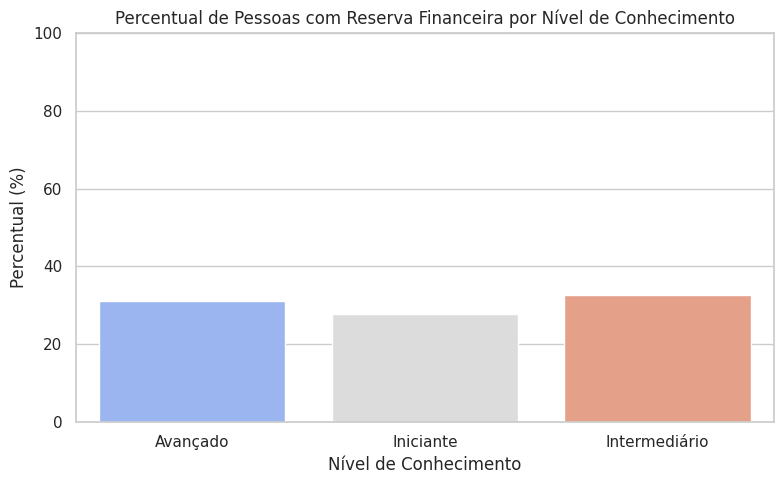

In [108]:
reserva_por_nivel = df_limpo.groupby('nivel_conhecimento')['reserva_financeira'].apply(lambda x: (x == 'Sim').mean() * 100).reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=reserva_por_nivel, x='nivel_conhecimento', y='reserva_financeira', palette='coolwarm')

plt.title('Percentual de Pessoas com Reserva Financeira por Nível de Conhecimento')
plt.xlabel('Nível de Conhecimento')
plt.ylabel('Percentual (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


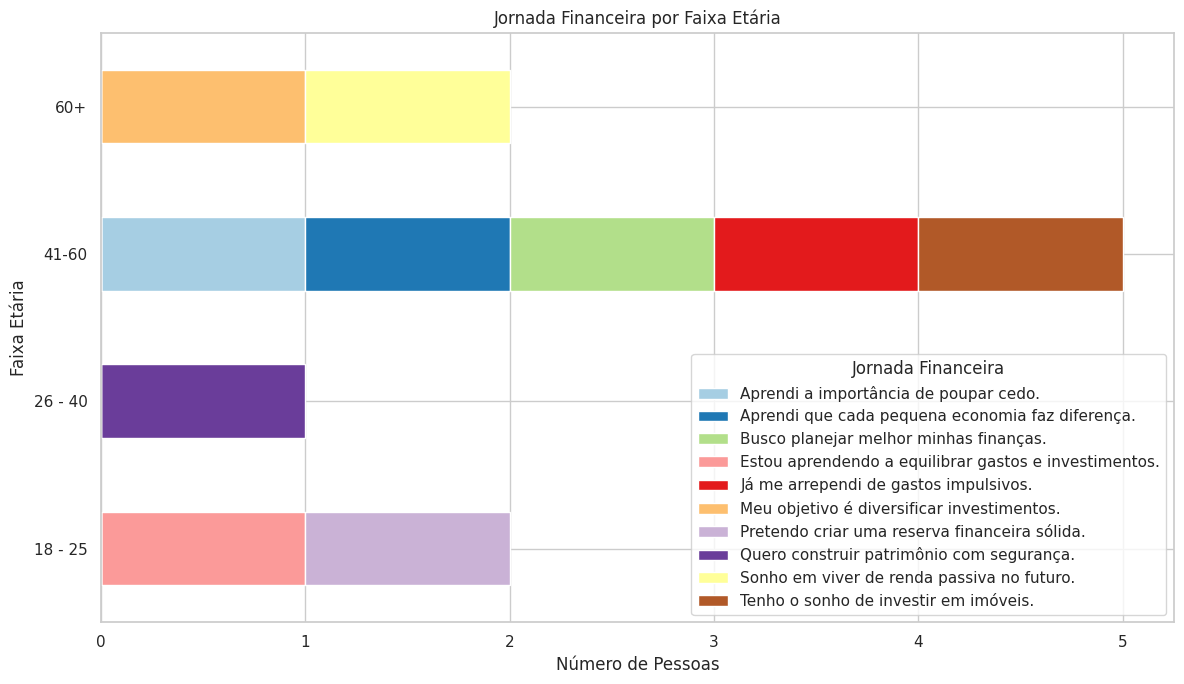

In [109]:
jornada_idade = df_limpo.groupby(['faixa_etaria', 'jornada_financeira']).size().reset_index(name='quantidade')
jornada_pivot = jornada_idade.pivot(index='faixa_etaria', columns='jornada_financeira', values='quantidade').fillna(0)

jornada_pivot.plot(kind='barh', stacked=True, figsize=(12,7), colormap='Paired')

plt.title('Jornada Financeira por Faixa Etária')
plt.xlabel('Número de Pessoas')
plt.ylabel('Faixa Etária')
plt.legend(title='Jornada Financeira')
plt.tight_layout()
plt.show()


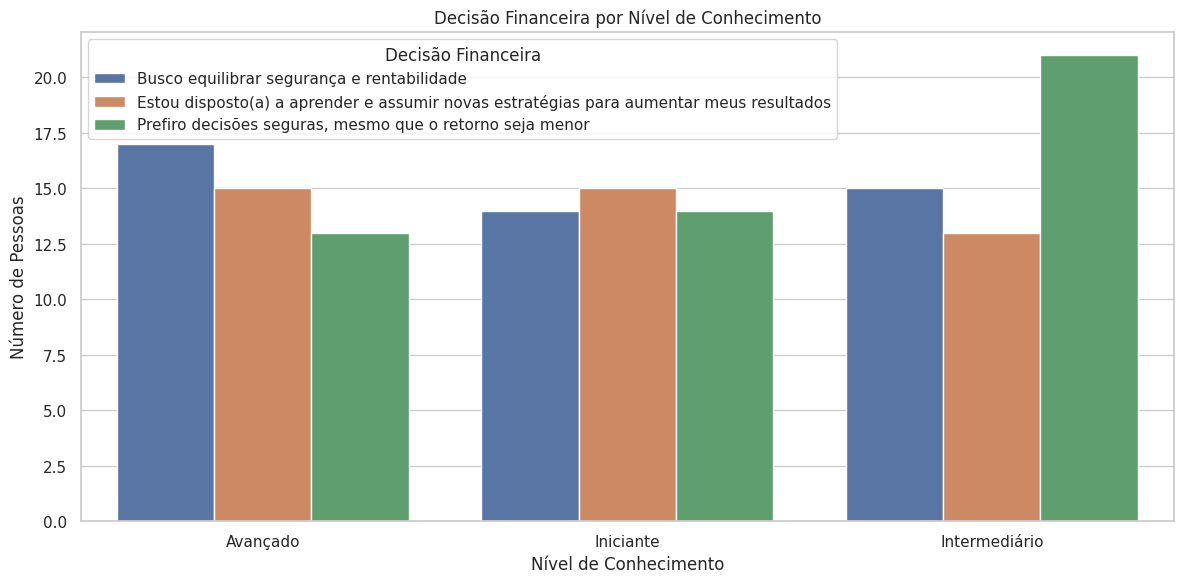

In [110]:
decisao_conhecimento = df_limpo.groupby(['nivel_conhecimento', 'decisao_financeira']).size().reset_index(name='quantidade')

plt.figure(figsize=(12,6))
sns.barplot(data=decisao_conhecimento, x='nivel_conhecimento', y='quantidade', hue='decisao_financeira')

plt.title('Decisão Financeira por Nível de Conhecimento')
plt.xlabel('Nível de Conhecimento')
plt.ylabel('Número de Pessoas')
plt.legend(title='Decisão Financeira')
plt.tight_layout()
plt.show()
